<a href="https://colab.research.google.com/github/kaapivalli/Research/blob/main/Copy_of_Final_RFR_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import xgboost
from xgboost.sklearn import XGBRegressor
#import xgboost as xgb
#reg = xgb.XGBRegressor(tree_method="hist")



#initial coding

In [ ]:
df.columns

In [ ]:
df

In [ ]:
# File path for the Excel file
FILEPATH = '/content/EPD data corrected may .xlsx'

# Read the single sheet
df = pd.read_excel(FILEPATH, sheet_name=1)  # Read the first (and only) sheet
print('Initial data head:')
print(df.head())
print('Columns:', df.columns.tolist())

print(df.shape)

# Define helper function to extract numeric value(s) and average them if more than one exists
def extract_numeric_avg(text):
    if pd.isna(text):
        return np.nan
    # Find all numbers (integers or decimals) in the text
    nums = re.findall(r'\d+\.?\d*', str(text))
    if not nums:
        return np.nan
    nums = [float(x) for x in nums]
    return np.mean(nums)

# Process columns: Voltage, Time, Concentration, pH, Zeta Potential
if 'Voltage (V)' in df.columns:
    df['Voltage_numeric'] = df['Voltage (V)'].apply(extract_numeric_avg)
else:
    print('Voltage column not found')

if 'Time (minutes)' in df.columns:
    df['Time_numeric'] = df['Time (minutes)'].apply(extract_numeric_avg)
else:
    print('Time column not found')

if 'Concentration (%)' in df.columns:
    df['Concentration_numeric'] = df['Concentration (%)'].apply(extract_numeric_avg)
else:
    print('Concentration column not found')

if 'pH' in df.columns:
    df['pH_numeric'] = df['pH'].apply(extract_numeric_avg)
else:
    print('pH column not found')

if 'Zeta Potential (mV)' in df.columns:
    df['Zeta_Potential_numeric'] = df['Zeta Potential (mV)'].apply(extract_numeric_avg)
else:
    print('Zeta Potential column not found')

# Handle thickness column
if 'Thickness (μm)' in df.columns:
    df['Thickness_numeric'] = df['Thickness (μm)'].apply(extract_numeric_avg)
else:
    print('Thickness column not found')

# Drop rows with missing essential columns
df_model = df.dropna(subset=['Voltage_numeric', 'Time_numeric', 'Concentration_numeric', 'pH_numeric', 'Zeta_Potential_numeric', 'Thickness_numeric']).copy()
print('Model Data head:')
print(df_model[['Voltage_numeric', 'Time_numeric', 'Concentration_numeric', 'pH_numeric', 'Zeta_Potential_numeric', 'Thickness_numeric']].head())

# Set up features and target
X = df_model[['Voltage_numeric', 'Time_numeric', 'Concentration_numeric', 'pH_numeric', 'Zeta_Potential_numeric']]
y = df_model['Thickness_numeric']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Make predictions
preds = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, preds)
print('Mean Squared Error: ' + str(mse))
print('Model training complete.')


In [ ]:
df_model

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:


# Example of a single test data point
single_data = {
    'Voltage_numeric': [80.0],  # Example value for Voltage (V)
    'Time_numeric': [03.0],    # Example value for Time (minutes)
    'Concentration_numeric': [2.5],  # Example value for Concentration
    'pH_numeric': [7.0],       # Example value for pH
    'Zeta_Potential_numeric': [22.0]  # Example value for Zeta Potential (mV)
}

# Convert the single data point into a DataFrame
single_df = pd.DataFrame(single_data)

# Make prediction using the trained model
single_pred = model.predict(single_df)

# Print the results
print("Single Test Data:")
print(single_df)
print("\nPredicted Thickness (μm) for the single data point:")
print(single_pred)


In [ ]:
#DF.to_excel('temp_sample.xlsx')

# rough work

In [ ]:
df[df['Thickness_numeric']>100]

In [ ]:
df['Thickness_numeric'].describe()

In [ ]:
df['Concentration_numeric'].describe()

In [ ]:
thickness_mean = 7.5
thickness_mean

In [ ]:
zp_mean = df['Zeta_Potential_numeric'].describe()['mean']
zp_mean

In [ ]:
ph_mean = df['pH_numeric'].describe()['mean']
ph_mean

In [ ]:
conc_mean = 3.0
conc_mean

In [ ]:
text = '0.23±2'
def func_for_conc_zp_thickness(text):
  text=str(text)
  if ('±' in text) or ('in' in text):
    tmp = re.findall(r'\d+\.?\d*', str(text))

    return(np.mean([float(tmp[0])]))
  else:
    #(re.findall(r'\d+\.?\d*', str(text)))
    return(np.mean([float(i) for i in re.findall(r'\d+\.?\d*', str(text))])) #Concentration, Zeta Potential, Thickness
func_for_conc_zp_thickness(text)

In [ ]:
text = '1hrs'
def func_for_time(text):
  text = str(text)
  tmp = re.findall(r'\d+\.?\d*', str(text))
  if 's' in text and 'mins' not in text and 'h' not in text:
    return(np.mean([float(tmp[0])/60]))
  elif 'hr' in text or 'hrs' in text:
    return(np.mean([float(tmp[0])*60]))
  else:
    return(np.mean([float(tmp[0])])) #Time

In [ ]:
DF

In [ ]:
type(df.loc[0,'pH_numeric'])

In [ ]:
DF['Time (minutes)'].apply(func_for_time)

In [ ]:
df['Time (minutes)'].apply(lambda x:re.findall('[^\d]',str(x))).value_counts()

In [ ]:
DF = df[df.columns[1:7]].copy()
DF

In [ ]:
#df = pd.read_excel('sample.xlsx')
#DF = pd.DataFrame()
def extract_numeric_avg(text):
    if pd.isna(text):
        return np.nan
    # Find all numbers (integers or decimals) in the text
    nums = re.findall(r'\d+\.?\d*', str(text))
    if not nums:
        return np.nan
    #nums = [float(x) for x in nums]
    return np.mean(nums)   #VOLTAGE


In [ ]:
def ensure_nan(text):
  nums = re.findall(r'\d+\.?\d*', str(text))
  #print(nums)
  if not nums:
    return np.nan
  else:
    return text

DF['Voltage (V)'] = DF['Voltage (V)']
DF['Time (minutes)'] = DF['Time (minutes)']
DF['Concentration'] = DF['Concentration (%)'].apply(ensure_nan)
DF['pH'] = DF['pH'].apply(ensure_nan)
DF['Zeta Potential (mV)'] = DF['Zeta Potential (mV)'].apply(ensure_nan)#, axis=1)
DF['Thickness (μm)'] = DF['Thickness (μm)'].apply(ensure_nan)

DF.dropna(how='any',inplace=True,axis=0)
DF


```
def ensure_nan(text):
  nums = re.findall(r'\d+\.?\d*', str(text))
  #print(nums)
  if not nums:
    return np.nan
  else:
    return text

DF['Voltage (V)'] = df['Voltage (V)']
DF['Time (minutes)'] = df['Time (minutes)']
DF['Concentration'] = df['Concentration'].apply(ensure_nan)
DF['pH'] = df['pH'].apply(ensure_nan)
DF['Zeta Potential (mV)'] = df['Zeta Potential (mV)'].apply(ensure_nan)#, axis=1)
DF['Thickness (μm)'] = df['Thickness (μm)'].apply(ensure_nan)




#STEPS TO FILL MISSING VALUES
DF['Thickness (μm)'] = DF['Thickness (μm)'].fillna(thickness_mean)#,axis=1)
DF['Zeta Potential (mV)'] = DF['Zeta Potential (mV)'].fillna(zp_mean)#, axis=1)
DF['pH'] = DF['pH'].fillna(ph_mean)#, axis=1)
DF['Concentration'] = DF['Concentration'].fillna(conc_mean)#, axis=1)
#df[['Voltage (V)','Time (minutes)','Concentration','Thickness (μm)','pH','Zeta Potential (mV)']].info()
```

In [ ]:
DF.info()

In [ ]:
DF

In [ ]:
#DF is the data with no missing values
#DF = df[['Voltage (V)','Time (minutes)','Concentration','Thickness (μm)','pH','Zeta Potential (mV)']].copy()
#DF.info()

In [ ]:
DF['voltage_numeric'] = DF['Voltage (V)'].apply(extract_numeric_avg)
DF['time_numeric'] = DF['Time (minutes)'].apply(func_for_time)
DF['conc_numeric'] = DF['Concentration (%)'].apply(func_for_conc_zp_thickness)
DF['ph_numeric'] = DF['pH'].apply(extract_numeric_avg)
DF['zp_numeric'] = DF['Zeta Potential (mV)'].apply(func_for_conc_zp_thickness)
DF['thickness_numeric'] = DF['Thickness (μm)'].apply(func_for_conc_zp_thickness)
DF

In [ ]:
DF['voltage_numeric'].describe()

In [ ]:
DF['conc_numeric'].describe()

In [ ]:
DF['time_numeric'].describe()

In [ ]:
DF['ph_numeric'].describe()

In [ ]:
DF['zp_numeric'].describe()

In [ ]:
DF['thickness_numeric'].describe()

In [ ]:
new_df = DF[['voltage_numeric','time_numeric','conc_numeric','ph_numeric','zp_numeric','thickness_numeric']]
new_df

In [ ]:
# @title voltage_numeric

from matplotlib import pyplot as plt
new_df['voltage_numeric'].plot(kind='hist', bins=20, title='voltage_numeric')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
new_df.to_excel('after clean.xlsx')

# 'after cleaned' - model training

In [ ]:
new_df = pd.read_excel('sample.xlsx',sheet_name='Sheet3')

In [ ]:
#new_df = new_df.sample(frac=1)
orig = new_df.iloc[:-33]
v_df = orig.iloc[-90:]
lit= orig.iloc[:-90].sample(100)
try_1 = pd.concat((lit,v_df),axis=0)
try_1

In [ ]:
vals = orig['zp_numeric'][orig['zp_numeric'].between(40,60)].values
new_2 = orig[orig['zp_numeric'].isin(vals)]
new_2

In [ ]:
#sns.boxplot(x=orig["zp_numeric"])
pd.concat((orig[orig['zp_numeric']>=40],orig[orig['zp_numeric']<=60]),axis=0)

In [ ]:
# Set up features and target
X = new_2[['voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric', 'zp_numeric']]
y = new_2['thickness_numeric']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Make predictions
preds = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, preds)
print('Mean Squared Error: ' + str(mse))
print('Model training complete.')


In [ ]:


# Example of a single test data point
single_data = {
    'voltage_numeric': [80.0],  # Example value for Voltage (V)
    'time_numeric': [03.0],    # Example value for Time (minutes)
    'conc_numeric': [2.5],  # Example value for Concentration
    'ph_numeric': [7.0],       # Example value for pH
    'zp_numeric': [22.0]  # Example value for Zeta Potential (mV)
}

# Convert the single data point into a DataFrame
single_df = pd.DataFrame(single_data)

# Make prediction using the trained model
single_pred = model.predict(single_df)

# Print the results
print("Single Test Data:")
print(single_df)
print("\nPredicted Thickness (μm) for the single data point:")
print(single_pred)


In [ ]:
#new_df.columns = ['Voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric',
#       'zp_numeric', 'thickness_numeric']

In [ ]:
# @title Voltage_numeric

from matplotlib import pyplot as plt
new_df['Voltage_numeric'].plot(kind='hist', bins=20, title='Voltage_numeric')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Set up features and target
from sklearn.svm import SVR
X = new_df[['Voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric', 'zp_numeric']]
y = new_df['thickness_numeric']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest model
model = SVR(C=1.0, epsilon=0.2)
model.fit(X_train, y_train)

# Make predictions
preds = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, preds)
print('Mean Squared Error: ' + str(mse))
print('Model training complete.')


In [ ]:


# Example of a single test data point
single_data = {
    'Voltage_numeric': [80.0],  # Example value for Voltage (V)
    'time_numeric': [03.0],    # Example value for Time (minutes)
    'conc_numeric': [2.5],  # Example value for Concentration
    'ph_numeric': [7.0],       # Example value for pH
    'zp_numeric': [22.0]  # Example value for Zeta Potential (mV)
}

# Convert the single data point into a DataFrame
single_df = pd.DataFrame(single_data)

# Make prediction using the trained model
single_pred = model.predict(single_df)

# Print the results
print("Single Test Data:")
print(single_df)
print("\nPredicted Thickness (μm) for the single data point:")
print(single_pred)


In [ ]:
new_df

In [ ]:
# @title conc_numeric

from matplotlib import pyplot as plt
new_df['conc_numeric'].plot(kind='hist', bins=20, title='conc_numeric')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
new_df

# 6th june try

In [ ]:
#print(new_df[['Voltage_numeric', 'Time_numeric', 'Concentration_numeric', 'pH_numeric', 'Zeta_Potential_numeric', 'Thickness_numeric']].head())
new_df = pd.read_csv('paper_work ML.csv')
# Set up features and target
X = new_df[['voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric','zp_numeric']]
y = new_df['thickness_numeric']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Make predictions
preds = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, preds)
print('Mean Squared Error: ' + str(mse))
print('Model training complete.')


Mean Squared Error: 3.5045103767647086
Model training complete.


In [ ]:
new_df.columns

Index(['voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric',
       'zp_numeric', 'thickness_numeric'],
      dtype='object')

In [ ]:
#new_df.to_csv('paper_work ML.csv',index=False)
pd.read_csv('paper_work ML.csv')

,voltage_numeric,time_numeric,conc_numeric,ph_numeric,zp_numeric,thickness_numeric
0,40.0,2.0,0.001,5.0,44.00,2.40
1,20.0,4.0,0.050,5.0,29.70,55.00
2,10.0,4.0,0.500,4.4,37.30,28.00
3,40.0,2.0,0.025,4.0,21.74,23.00
4,60.0,6.0,0.020,4.0,21.74,25.00
...,...,...,...,...,...,...
165,80.0,8.0,3.000,9.8,60.25,7.30
166,90.0,8.0,3.000,8.9,60.25,7.10
167,100.0,8.0,3.000,7.5,60.25,7.20
168,110.0,8.0,3.000,7.6,60.25,7.60


In [ ]:

def test_pred():
# Example of a single test data point
  single_data = {
      'voltage_numeric': [80.0],  # Example value for Voltage (V)
      'time_numeric': [03.0],    # Example value for Time (minutes)
      'conc_numeric': [3.0],  # Example value for Concentration
      'ph_numeric': [7.0],       # Example value for pH
      'zp_numeric': [42.0]  # Example value for Zeta Potential (mV)
  }

  # Convert the single data point into a DataFrame
  single_df = pd.DataFrame(single_data)

  # Make prediction using the trained model
  single_pred = model.predict(single_df)

  # Print the results
  print("Single Test Data:")
  print(single_df)
  print("\nPredicted Thickness (μm) for the single data point:")
  print(single_pred)


In [ ]:
test_pred()

Single Test Data:
   voltage_numeric  time_numeric  conc_numeric  ph_numeric  zp_numeric
0             80.0           3.0           3.0         7.0        42.0

Predicted Thickness (μm) for the single data point:
[17.103]


In [ ]:
parameters_rfr = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [1,2,3,4],
}
from sklearn.model_selection import GridSearchCV
rfr = RandomForestRegressor(random_state=0)

clf = GridSearchCV(rfr, parameters_rfr)

clf.fit(X, y)

clf.cv_results_

{'mean_fit_time': array([0.2035953 , 0.24663444, 0.22810206, 0.28927407, 0.42656236,
        0.11843204, 0.17822881, 0.23540511, 0.30314059, 0.57514396,
        0.12219934, 0.17765923, 0.24725413, 0.29709373, 0.36310096,
        0.12779727, 0.18488612, 0.24539032, 0.49442754, 0.40099397]),
 'std_fit_time': array([0.01210978, 0.05790637, 0.0069816 , 0.00933362, 0.09914272,
        0.00274958, 0.00582142, 0.00679222, 0.01305756, 0.06987021,
        0.00556726, 0.00272324, 0.01040538, 0.01012988, 0.01100286,
        0.00590566, 0.00651977, 0.00813348, 0.03882992, 0.0655928 ]),
 'mean_score_time': array([0.01889558, 0.01709104, 0.01847386, 0.0233222 , 0.03732901,
        0.01020803, 0.01367545, 0.01798196, 0.02672133, 0.04010005,
        0.01150141, 0.014429  , 0.01780415, 0.02164249, 0.02606077,
        0.01077561, 0.01443834, 0.01808558, 0.03699036, 0.02867374]),
 'std_score_time': array([5.83718825e-03, 4.45341855e-03, 1.74529510e-03, 4.15833709e-03,
        1.04654321e-02, 6.99594405e-

In [ ]:
clf.best_estimator_

RandomForestRegressor(max_depth=4, random_state=0)

In [ ]:
clf.best_params_

{'max_depth': 4, 'n_estimators': 100}

In [ ]:
single_data1 = {
      'voltage_numeric': [80.0],  # Example value for Voltage (V)
      'time_numeric': [03.0],    # Example value for Time (minutes)
      'conc_numeric': [3.0],  # Example value for Concentration
      'ph_numeric': [7.0],       # Example value for pH
      'zp_numeric': [40.5]  # Example value for Zeta Potential (mV)
  }
#single_data = {
#    'voltage_numeric': [80.0],  # Example value for Voltage (V)
#    'time_numeric': [03.0],    # Example value for Time (minutes)
#    'conc_numeric': [2.5],  # Example value for Concentration
#    'ph_numeric': [7.0],       # Example value for pH
#    'zp_numeric': [22.0]  # Example value for Zeta Potential (mV)
#}

  # Convert the single data point into a DataFrame
#single_df = pd.DataFrame(single_data)
single_df1 = pd.DataFrame(single_data1)

In [ ]:
clf.predict(single_df1)

array([21.0555911])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test.shape

(34, 5)

In [ ]:
y_test.shape

(34,)

In [ ]:
clf

GridSearchCV(estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [1, 2, 3, 4],
                         'n_estimators': [100, 150, 200, 250, 300]})

# check errors

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
import pickle

# Assuming 'model' is your fitted model
#filename = 'Final_RFR_model.pkl'
#with open(filename, 'wb') as file:
#  pickle.dump(clf, file)

with open(filename, 'rb') as file:
        clf = pickle.load(file)

In [ ]:
new_df = pd.read_csv('paper_work ML.csv')
X = new_df[['voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric','zp_numeric']]
y = new_df['thickness_numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rfr = RandomForestRegressor(random_state=0,max_depth = 4, n_estimators=100)
rfr.fit(X_train,y_train)
preds = rfr.predict(X_test)  # previously clf instead of rfr
#preds = clf.predict(X_test)
preds

array([ 7.33116968,  7.16306828,  7.3135932 ,  7.32307276,  7.29458832,
        7.29036133,  7.29537141,  7.27956339,  7.34200137,  7.15100473,
        7.21880664,  7.32902851,  7.30928659,  7.30469025,  7.34266123,
        7.26304045,  7.2866151 ,  7.31688395,  7.26574829,  7.3513372 ,
        7.25472067,  7.22383849,  7.26906487,  7.29257465,  7.21108066,
       23.066     ,  7.25701548,  7.26914987,  7.26863948,  7.30271707,
        7.29722855,  7.30464823,  7.21241158,  7.32469319])

In [ ]:
def get_all_errors(y_pred,y_test):
  mae = mean_absolute_error(y_test,y_pred)
  mape = mean_absolute_percentage_error(y_test,y_pred)
  mse = mean_squared_error(y_test,y_pred)
  r2 = r2_score(y_test,y_pred)
  print(f"{mae = }, {mape = }, {mse = }, {r2 = }")

In [ ]:
pd.DataFrame(data={'predicted':preds,'test':y_test}).to_csv('rfr predict and test val.csv',index=False)

In [ ]:
rfr_pred_test = pd.read_csv('rfr predict and test val.csv')
preds = rfr_pred_test.predicted.values
y_test = rfr_pred_test.test.values

In [ ]:
get_all_errors(preds,y_test) #RANDOM FOREST REGRESSOR'S SCORES ; MODEL PARAMS = {'max_depth': 4, 'n_estimators': 100, 'random_state': 0}

mae = 0.19606353078211725, mape = 0.021573114958679654, mse = 0.34812120017602727, r2 = 0.4356981164886673


## xgboost

In [ ]:
new_df = pd.read_csv('paper_work ML.csv')
X = new_df[[
    'voltage_numeric', 'time_numeric', 'conc_numeric', 'ph_numeric','zp_numeric']]
y = new_df['thickness_numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
xgb1 = XGBRegressor() #https://www.kaggle.com/code/jayatou/xgbregressor-with-gridsearchcv
parameters = {'nthread':[1,2,3,4,5], #when use hyperthread, xgboost may become slower
              #'objective':['reg:linear'],
              'learning_rate': [0.03, 0.05,0.1,0.01,1.0], #so called `eta` value
              'max_depth': [3,4,5, 6,7],
              'min_child_weight': [3,4,5,6,7],
             # 'silent': [1],
              'subsample': [0.4,0.6,0.7,0.8],
              'colsample_bytree': [0.4,0.6,0.7,0.8],
              'n_estimators': [100, 200,300,400,500]}
parameters = {'nthread':[4], #when use hyperthread, xgboost may become slower
              'objective':['reg:linear'],
              'learning_rate': [.03, 0.05, .07], #so called `eta` value
              'max_depth': [5, 6, 7],
              'min_child_weight': [4],
              'silent': [1],
              'subsample': [0.7],
              'colsample_bytree': [0.7],
              'n_estimators': [100,400,500]}
xgb_grid2 = GridSearchCV(xgb1,
                        parameters,
                        cv = 2,
                        n_jobs = 5,
                        verbose=True)

xgb_grid2.fit(X,y)

print(xgb_grid2.best_score_)
print(xgb_grid2.best_params_)

Fitting 2 folds for each of 27 candidates, totalling 54 fits
-55.65518675914751
{'colsample_bytree': 0.7, 'learning_rate': 0.07, 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 400, 'nthread': 4, 'objective': 'reg:linear', 'silent': 1, 'subsample': 0.7}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:39:48] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:39:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
xgb_grid2.predict(single_df1)

array([12.7518635], dtype=float32)

In [ ]:
y_pred = xgb_grid2.predict(X_test)
get_all_errors(y_pred,y_test)

mae = 0.14522341447718004, mape = 0.016224082920613402, mse = 0.17860837279388564, r2 = 0.7104771524184106


In [ ]:
pd.DataFrame(data={'xgboost_predicted':y_pred,'y_test':y_test}).to_csv('xgboost_prediction_and_y_test.csv')

In [ ]:
pd.read_csv('xgboost_prediction_and_y_test.csv')

,Unnamed: 0,xgboost_predicted,y_test
0,139,7.196496,7.30
1,30,6.985779,7.10
2,119,7.127022,7.10
3,29,7.520028,7.30
4,144,7.205368,7.20
5,163,7.258301,7.40
6,166,7.255904,7.10
7,51,7.252601,7.20
8,105,7.335302,7.10
9,60,6.989379,7.10


In [ ]:
import pickle

# Assuming 'model' is your fitted model
filename = 'Final_xgboost_model.pkl'
with open(filename, 'wb') as file:
  pickle.dump(xgb_grid2, file)

with open(filename, 'rb') as file:
        clf = pickle.load(file)

In [ ]:
#xgb1 = XGBRegressor(n_estimators= 100)
#xgb1.fit(X_train,y_train)
#xgb1.predict(single_df1) #9.085077

## SVR

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)
X = np.concatenate((X_train,X_test),axis=0)
y = np.concatenate((y_train,y_test))
X.shape,y.shape

((170, 5), (170,))

In [ ]:
parameters=[{'C': [0.1,0.01,0.5,0.001,1,10,100],'kernel':['rbf','linear','poly','sigmoid'],'gamma': ['scale','auto',0.01,0.1, 0.2, 0.3, 0.4, 0.5,0.6,0.7]}]
model_svr=SVR()  #https://github.com/Venkatadattak/SVR-with-GridSearchCV/blob/master/SVR.ipynb
grid_search_svr=GridSearchCV(estimator=model_svr,
                         param_grid=parameters,
                         cv=5,
                         n_jobs=-1,verbose=2)
grid_search_svr=grid_search_svr.fit(X,y)

Fitting 5 folds for each of 280 candidates, totalling 1400 fits


In [ ]:
grid_search_svr.best_params_,grid_search_svr.best_score_

({'C': 0.001, 'gamma': 0.3, 'kernel': 'poly'}, np.float64(0.12578589327728443))

In [ ]:
single_df1.values

array([[80. ,  3. ,  3. ,  7. , 40.5]])

In [ ]:
sc.transform(single_df1.values)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 0.26554951, -0.64047855,  0.99281151, -0.86498696, -2.20929   ]])

In [ ]:
grid_search_svr.predict([[ 0.26554951, -0.64047855,  0.99281151, -0.86498696, -2.20929   ]])  #{'C': 0.001, 'gamma': 0.3, 'kernel': 'poly'}, np.float64(0.12578589327728443) --> 7.4719968

                                                                                                #mae = 0.13644437420515437, mape = 0.017619359950740758, mse = 0.030839246321802512, r2 = 0.9500098104434218


array([7.4719968])

In [ ]:
preds = grid_search_svr.predict(X_test)
get_all_errors(preds,y_test)

mae = 0.13644437420515437, mape = 0.017619359950740758, mse = 0.030839246321802512, r2 = 0.9500098104434218


In [ ]:
pd.DataFrame(data={'svr_predicted':preds,'y_test':y_test}).to_csv('svr_prediction_and_y_test.csv')

In [ ]:
import pickle

# Assuming 'model' is your fitted model
filename = 'Final_SVR_model.pkl'
with open(filename, 'wb') as file:
  pickle.dump(grid_search_svr, file)

with open(filename, 'rb') as file:
        clf = pickle.load(file)

### svr discarded readings

In [ ]:
model_svr = SVR(kernel='rbf')
model_svr.fit(X_train,y_train)
print(model_svr.predict([[ 0.26554951, -0.64047855,  0.99281151, -0.86498696, -2.20929   ]]))
y_pred = model_svr.predict(X_test)
get_all_errors(y_pred,y_test)

In [ ]:
#model_svr = SVR(C = 0.001, gamma = 0.3, kernel = 'poly')
parameters=[{'C': [0.1,0.01,0.5,0.001,1,10,100],'kernel':['rbf','linear','poly','sigmoid'],'gamma': ['scale','auto',0.01,0.1, 0.2, 0.3, 0.4, 0.5,0.6,0.7]}]
model_svr=SVR()  #https://github.com/Venkatadattak/SVR-with-GridSearchCV/blob/master/SVR.ipynb
grid_search_svr=GridSearchCV(estimator=model_svr,
                         param_grid=parameters,
                         cv=5,
                         n_jobs=-1,verbose=2)
grid_search_svr=grid_search_svr.fit(X,y)

In [ ]:
grid_search_svr.best_params_

In [ ]:
grid_search_svr.predict(single_df1)

In [ ]:
preds = grid_search_svr.predict(X_test)
get_all_errors(preds,y_test)

In [ ]:
model_svr = SVR(kernel='linear')
model_svr.fit(X_train,y_train)
model_svr.predict(single_df1)

In [ ]:
preds = model_svr.predict(X_test)
get_all_errors(preds,y_test)

In [ ]:
pd.DataFrame(data={'svr_predicted':preds,'y_test':y_test}).to_csv('svr_prediction_and_y_test.csv')

In [ ]:
import pickle

# Assuming 'model' is your fitted model
filename = 'Final_SVR_model.pkl'
with open(filename, 'wb') as file:
  pickle.dump(grid_search_svr, file)

with open(filename, 'rb') as file:
        clf = pickle.load(file)

#RF VIZ

In [ ]:
import pickle

# Assuming 'model' is your fitted model
filename = 'Final_RFR_model.pkl'
#with open(filename, 'wb') as file:
#  pickle.dump(clf, file)

with open(filename, 'rb') as file:
        clf_rf = pickle.load(file)

filename = 'Final_SVR_model.pkl'
#with open(filename, 'wb') as file:
#  pickle.dump(grid_search_svr, file)

with open(filename, 'rb') as file:
        clf_svr = pickle.load(file)

#import pickle

# Assuming 'model' is your fitted model
filename = 'Final_xgboost_model.pkl'
#ith open(filename, 'wb') as file:
#  pickle.dump(xgb_grid2, file)

with open(filename, 'rb') as file:
        clf_xgb = pickle.load(file)

/tmp/ipython-input-3120647454.py:26: UserWarning: [20:42:57] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  clf_xgb = pickle.load(file)


In [ ]:
prediction_svr = pd.read_csv('/content/svr_prediction_and_y_test.csv',index_col = 'Unnamed: 0')
prediction_rf = pd.read_csv('/content/rfr predict and test val.csv')#,index_col = 'Unnamed: 0')
prediction_xgb = pd.read_csv('/content/xgboost_prediction_and_y_test.csv',index_col = 'Unnamed: 0')
prediction_xgb

,xgboost_predicted,y_test
139,7.196496,7.30
30,6.985779,7.10
119,7.127022,7.10
29,7.520028,7.30
144,7.205368,7.20
163,7.258301,7.40
166,7.255904,7.10
51,7.252601,7.20
105,7.335302,7.10
60,6.989379,7.10


In [ ]:
prediction_svr

,svr_predicted,y_test
139,7.254045,7.30
30,7.312991,7.10
119,7.279971,7.10
29,7.320471,7.30
144,7.241228,7.20
163,7.296447,7.40
166,7.281739,7.10
51,7.302020,7.20
105,7.277852,7.10
60,7.304514,7.10


In [ ]:
# @title predicted vs test

from matplotlib import pyplot as plt
prediction_rf.plot(kind='scatter', x='predicted', y='test', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
new_df = pd.read_csv('paper_work ML.csv')

In [ ]:
new_df.columns = ['Voltage','Time','Concentration','pH','ZetaPotential','Thickness']
new_df

,Voltage,Time,Concentration,pH,ZetaPotential,Thickness
0,40.0,2.0,0.001,5.0,44.00,2.40
1,20.0,4.0,0.050,5.0,29.70,55.00
2,10.0,4.0,0.500,4.4,37.30,28.00
3,40.0,2.0,0.025,4.0,21.74,23.00
4,60.0,6.0,0.020,4.0,21.74,25.00
...,...,...,...,...,...,...
165,80.0,8.0,3.000,9.8,60.25,7.30
166,90.0,8.0,3.000,8.9,60.25,7.10
167,100.0,8.0,3.000,7.5,60.25,7.20
168,110.0,8.0,3.000,7.6,60.25,7.60


In [ ]:
X = new_df[['Voltage','Time','Concentration','pH','ZetaPotential']]
y = new_df['Thickness']
X

,Voltage,Time,Concentration,pH,ZetaPotential
0,40.0,2.0,0.001,5.0,44.00
1,20.0,4.0,0.050,5.0,29.70
2,10.0,4.0,0.500,4.4,37.30
3,40.0,2.0,0.025,4.0,21.74
4,60.0,6.0,0.020,4.0,21.74
...,...,...,...,...,...
165,80.0,8.0,3.000,9.8,60.25
166,90.0,8.0,3.000,8.9,60.25
167,100.0,8.0,3.000,7.5,60.25
168,110.0,8.0,3.000,7.6,60.25


In [ ]:
X_test = X.iloc[prediction_svr.index]
y_test = new_df.iloc[prediction_svr.index]['Thickness']
X_train = X.drop(index=X_test.index)
y_train = new_df.drop(index=X_test.index)['Thickness']
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((136, 5), (136,), (34, 5), (34,))

In [ ]:
X_train

,Voltage,Time,Concentration,pH,ZetaPotential
0,40.0,2.0,0.001,5.0,44.00
1,20.0,4.0,0.050,5.0,29.70
2,10.0,4.0,0.500,4.4,37.30
3,40.0,2.0,0.025,4.0,21.74
4,60.0,6.0,0.020,4.0,21.74
...,...,...,...,...,...
164,70.0,8.0,3.000,8.9,60.25
165,80.0,8.0,3.000,9.8,60.25
167,100.0,8.0,3.000,7.5,60.25
168,110.0,8.0,3.000,7.6,60.25


In [ ]:
clf_rf.predict(X_test.values)

In [ ]:
RF = RandomForestRegressor(max_depth = 4, n_estimators = 100, random_state = 0)
RF.fit(X_train,y_train)
pred_rf = RF.predict(X_test)
#preds = model_svr.predict(X_test)
print(RF.predict(single_df1.values))
get_all_errors(pred_rf,y_test)

In [ ]:
prediction_xgb

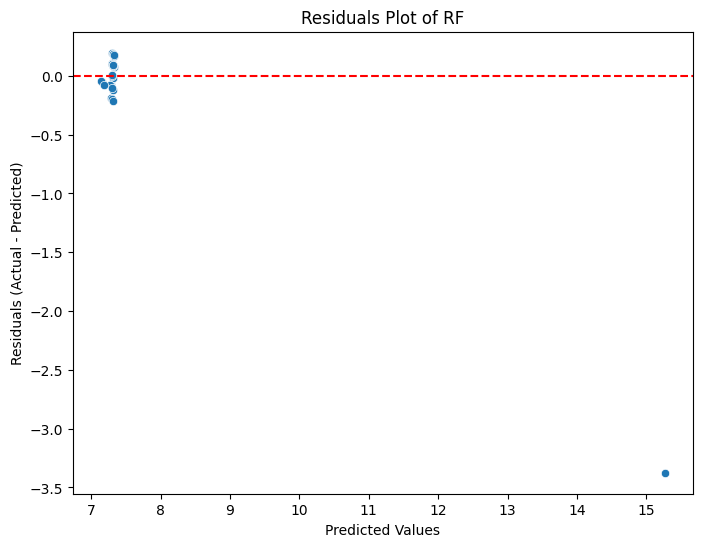

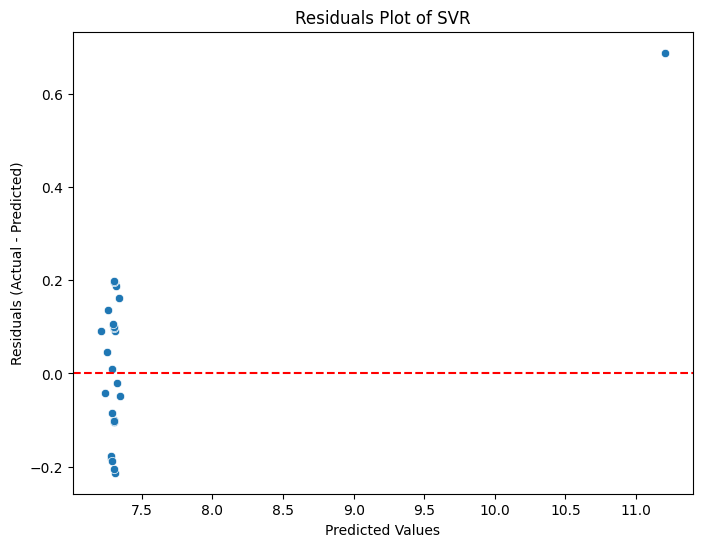

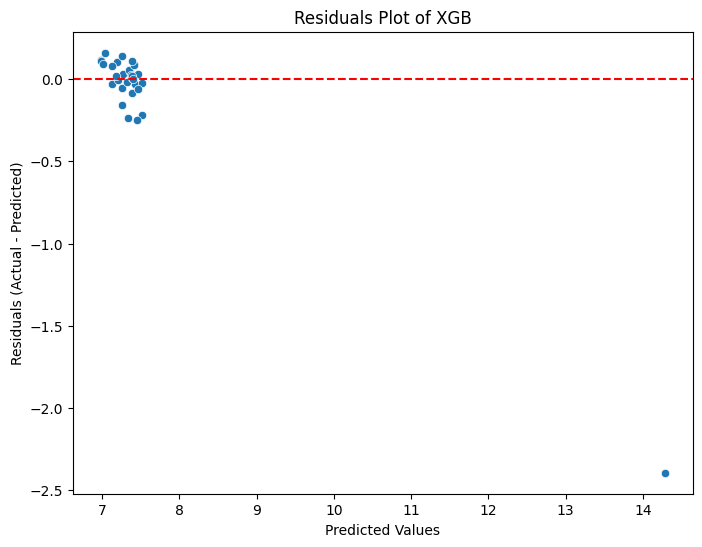

In [ ]:
#RESIDUAL PLOT OF RF

import matplotlib.pyplot as plt
import seaborn as sns

residuals_rf = prediction_rf.test.values - prediction_rf.predicted.values
residuals_svr = prediction_svr.y_test.values - prediction_svr.svr_predicted.values
residuals_xgb = prediction_xgb.y_test.values - prediction_xgb.xgboost_predicted.values


plt.figure(figsize=(8, 6))
sns.scatterplot(x=prediction_rf.predicted.values, y=residuals_rf)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals Plot of RF')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=prediction_svr.svr_predicted.values, y = residuals_svr)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals Plot of SVR')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=prediction_xgb.xgboost_predicted.values,y = residuals_xgb)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals Plot of XGB')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()


In [ ]:
new_prediction_rf = pd.concat((prediction_rf,pd.DataFrame({'predicted':21.0555911,'test':21.0},index=[0])),axis=0,ignore_index=True)
new_prediction_rf


,predicted,test
0,7.314359,7.30
1,7.151453,7.10
2,7.289297,7.10
3,7.309255,7.30
4,7.289613,7.20
5,7.291542,7.40
6,7.299556,7.10
7,7.281343,7.20
8,7.312794,7.10
9,7.141097,7.10


In [ ]:
new_prediction_svr = pd.concat((prediction_svr,pd.DataFrame({'svr_predicted':7.4719968,'y_test':21.0},index=[0])),axis=0,ignore_index=True)
new_prediction_svr

,svr_predicted,y_test
0,7.254045,7.30
1,7.312991,7.10
2,7.279971,7.10
3,7.320471,7.30
4,7.241228,7.20
5,7.296447,7.40
6,7.281739,7.10
7,7.302020,7.20
8,7.277852,7.10
9,7.304514,7.10


In [ ]:
new_prediction_xgb = pd.concat((prediction_xgb,pd.DataFrame({'xgboost_predicted':12.7518635,'y_test':21.0},index=[0])),axis=0,ignore_index=True)
new_prediction_xgb

,xgboost_predicted,y_test
0,7.196496,7.30
1,6.985779,7.10
2,7.127022,7.10
3,7.520028,7.30
4,7.205368,7.20
5,7.258301,7.40
6,7.255904,7.10
7,7.252601,7.20
8,7.335302,7.10
9,6.989379,7.10


In [ ]:
prediction_rf_dropped = prediction_rf.drop(index=[25])

In [ ]:
prediction_svr_dropped = prediction_svr.drop(index=[9])

In [ ]:
prediction_xgb_dropped = prediction_xgb.drop(index=[9])

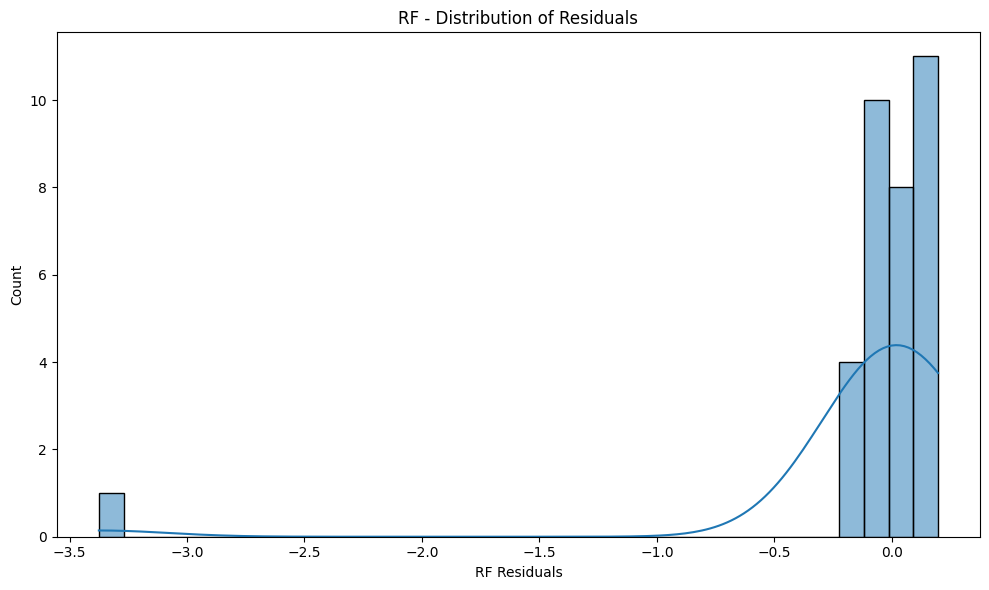

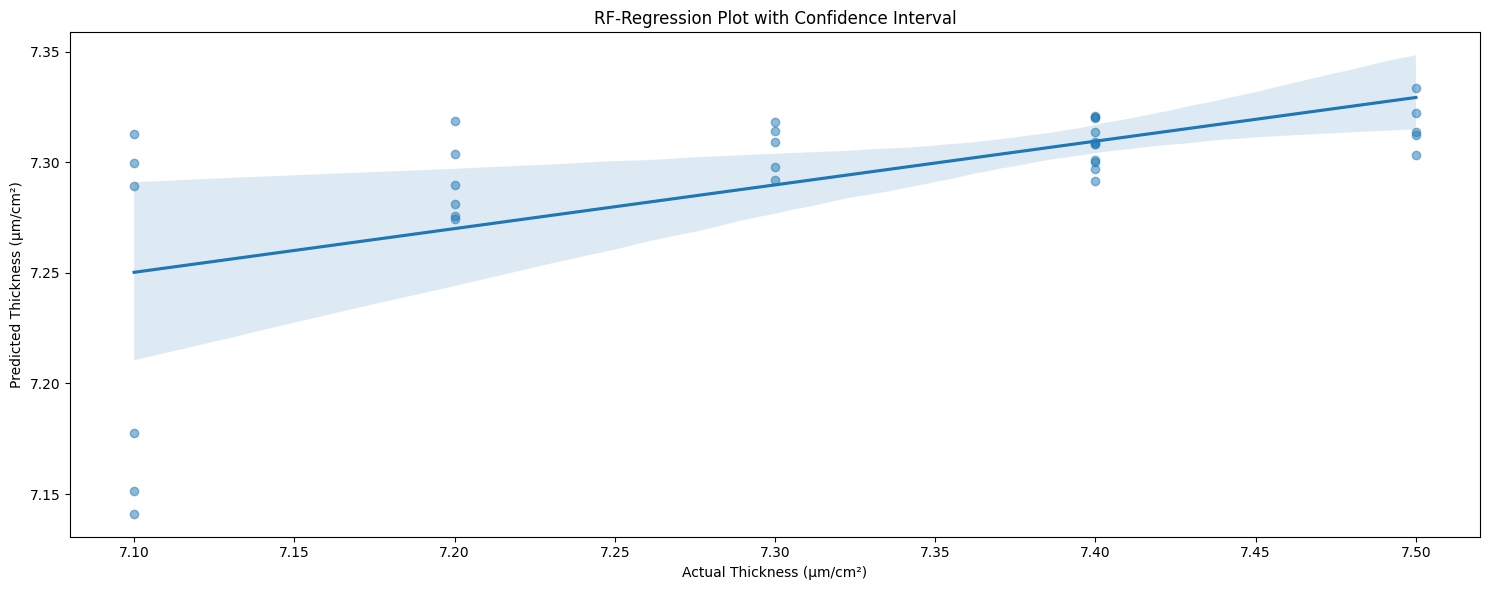

In [ ]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True)
plt.xlabel('RF Residuals')
plt.ylabel('Count')
plt.title('RF - Distribution of Residuals')
plt.tight_layout()
plt.show()

# Create a regression plot
plt.figure(figsize=(15, 6))
sns.regplot(x=prediction_rf_dropped.test.values, y=prediction_rf_dropped.predicted.values, scatter_kws={'alpha':0.5})
plt.xlabel('Actual Thickness (µm/cm²)')
plt.ylabel('Predicted Thickness (µm/cm²)')
plt.title('RF-Regression Plot with Confidence Interval')
plt.tight_layout()
plt.show()

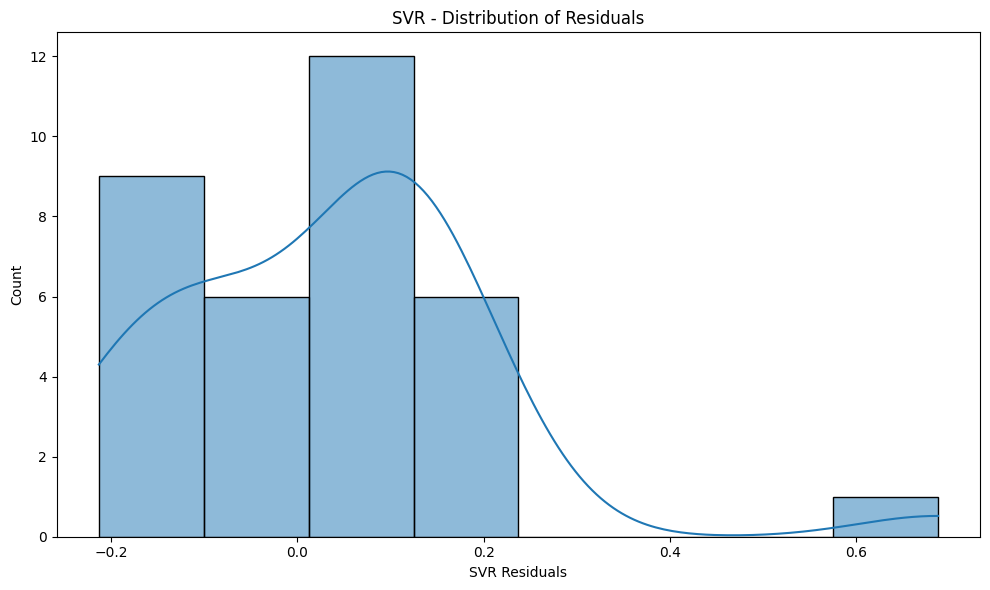

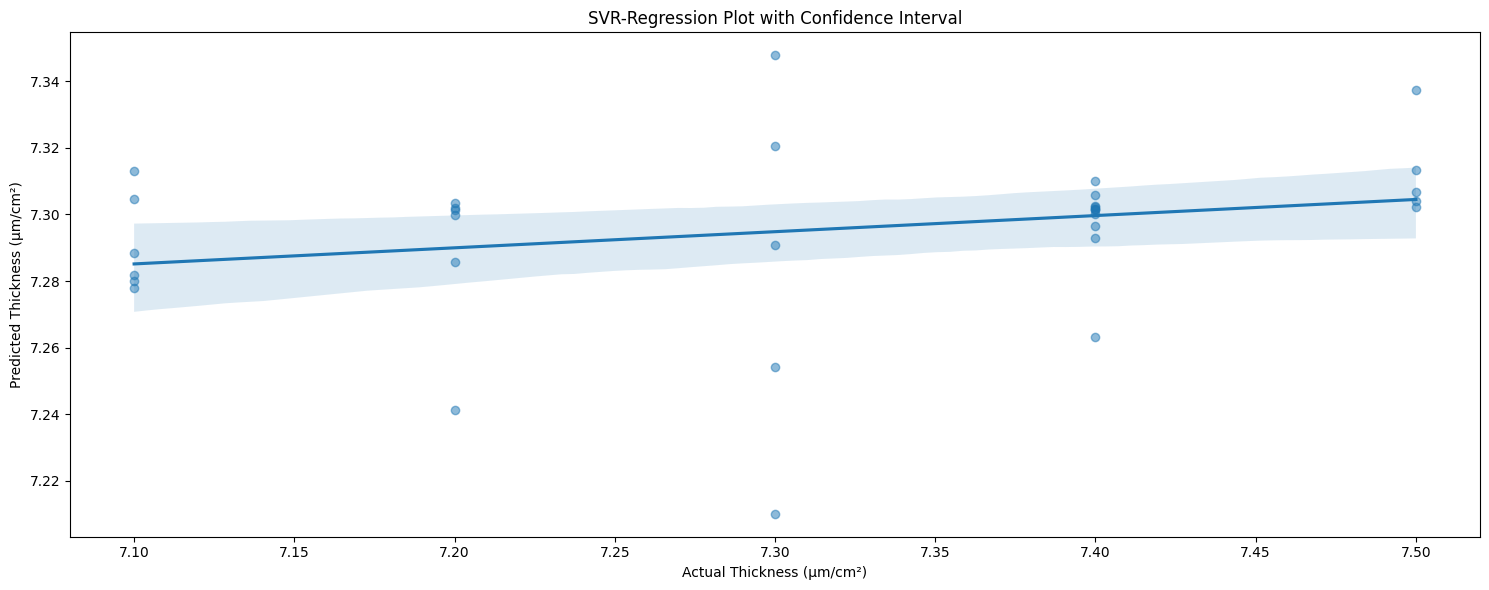

In [ ]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_svr, kde=True)
plt.xlabel('SVR Residuals')
plt.ylabel('Count')
plt.title('SVR - Distribution of Residuals')
plt.tight_layout()
plt.show()

# Create a regression plot
plt.figure(figsize=(15, 6))
sns.regplot(x=prediction_svr_dropped.y_test.values, y=prediction_svr_dropped.svr_predicted.values, scatter_kws={'alpha':0.5})
plt.xlabel('Actual Thickness (µm/cm²)')
plt.ylabel('Predicted Thickness (µm/cm²)')
plt.title('SVR-Regression Plot with Confidence Interval')
plt.tight_layout()
plt.show()

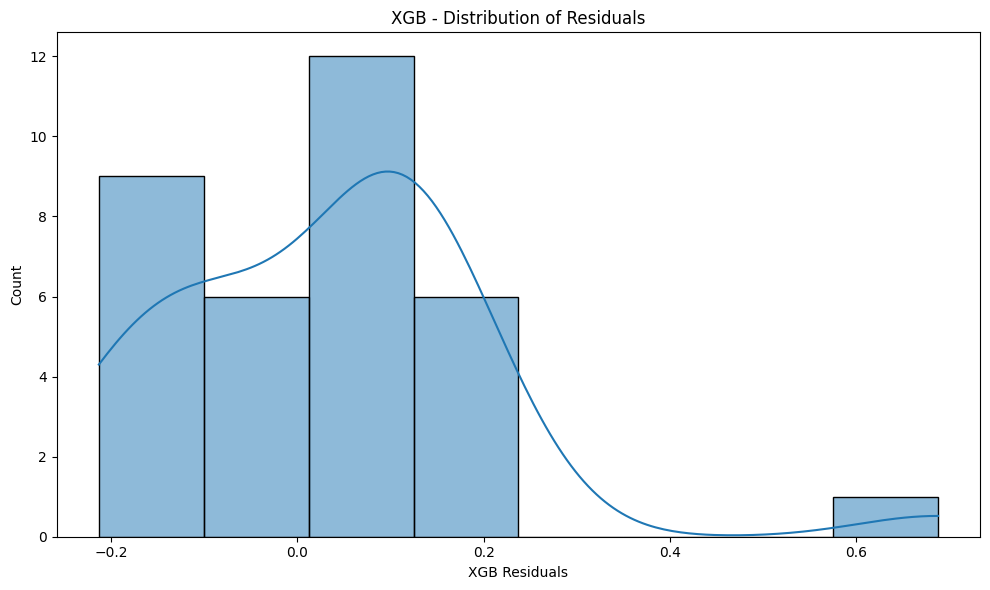

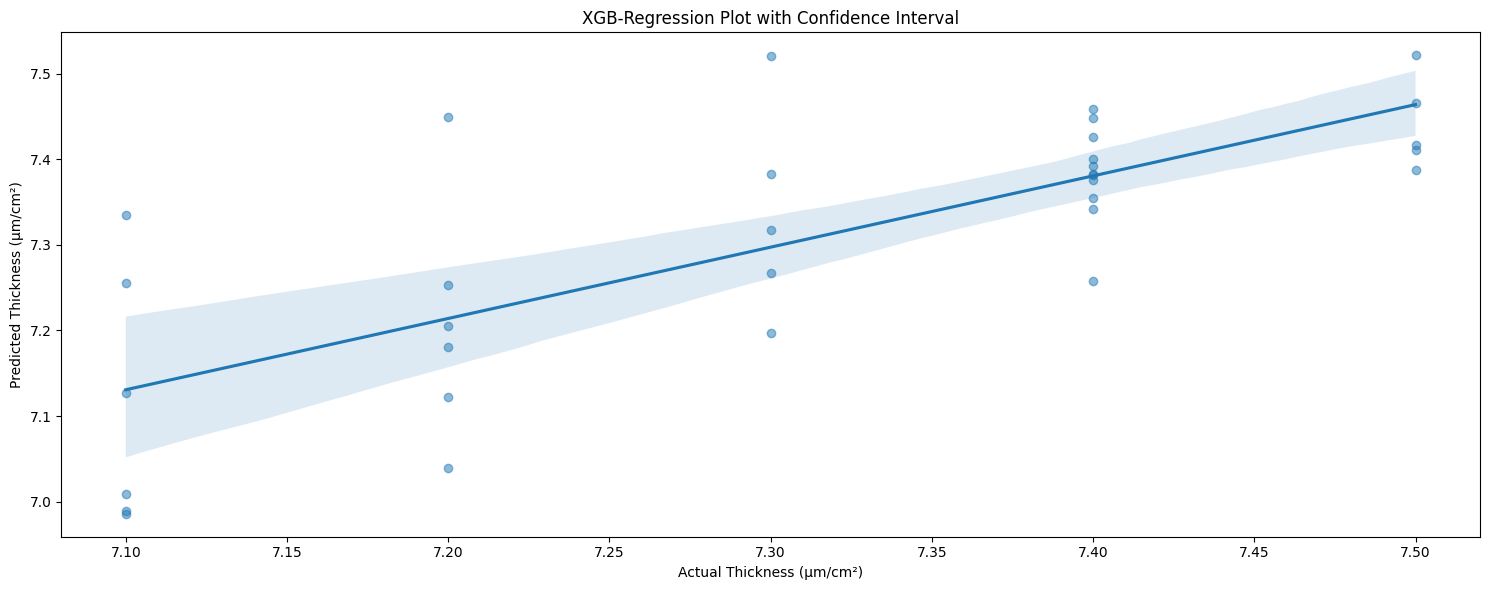

In [ ]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_svr, kde=True)
plt.xlabel('XGB Residuals')
plt.ylabel('Count')
plt.title('XGB - Distribution of Residuals')
plt.tight_layout()
plt.show()

# Create a regression plot
plt.figure(figsize=(15, 6))
sns.regplot(x=prediction_xgb_dropped.y_test.values, y=prediction_xgb_dropped.xgboost_predicted.values, scatter_kws={'alpha':0.5})
plt.xlabel('Actual Thickness (µm/cm²)')
plt.ylabel('Predicted Thickness (µm/cm²)')
plt.title('XGB-Regression Plot with Confidence Interval')
plt.tight_layout()
plt.show()

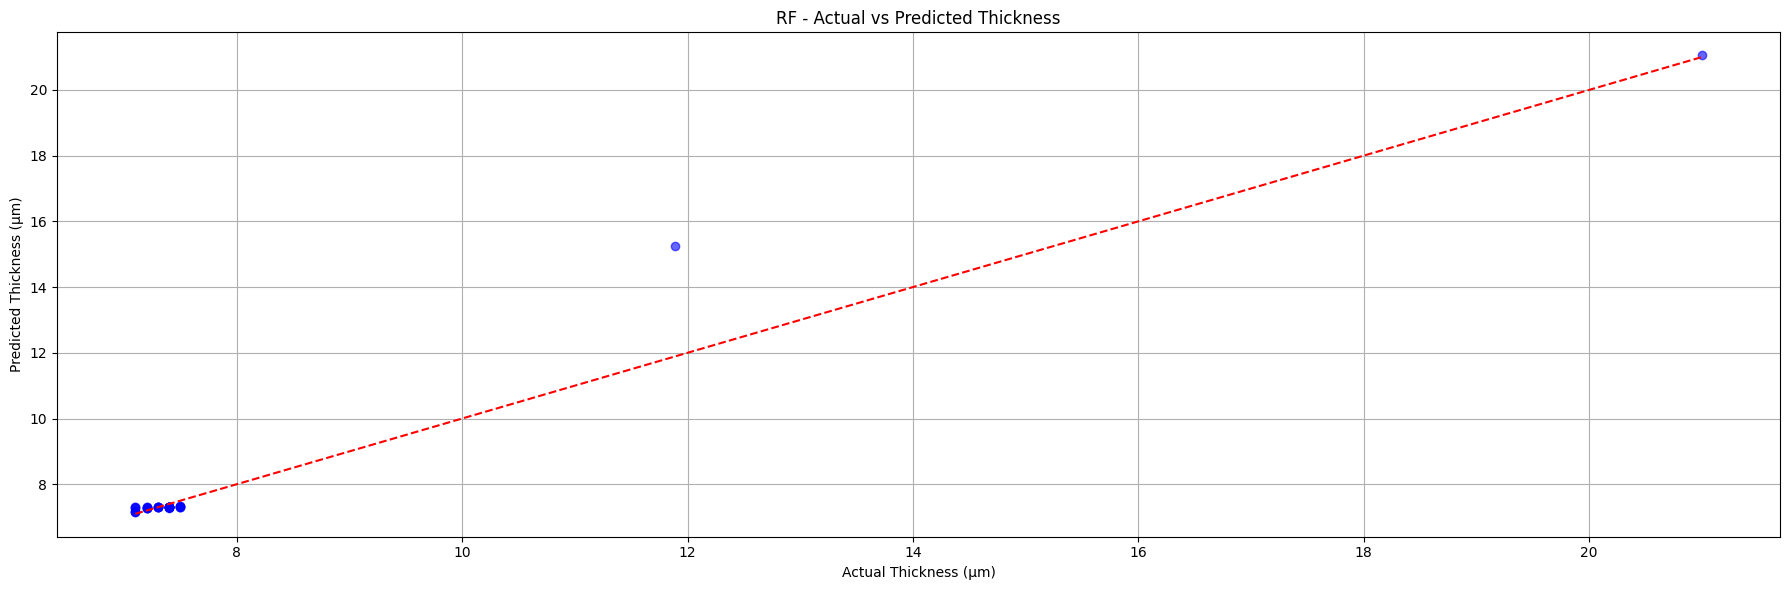

In [ ]:
import matplotlib.pyplot as plt
#prediction_rf.test.values - prediction_rf.predicted.values
plt.figure(figsize=(18,6))
plt.scatter(new_prediction_rf.test.values, new_prediction_rf.predicted.values, color='blue', alpha=0.6)
plt.plot([new_prediction_rf.test.values.min(), new_prediction_rf.test.values.max()], [new_prediction_rf.test.values.min(), new_prediction_rf.test.values.max()], 'r--')  # 45-degree line
plt.xlabel('Actual Thickness (µm)')
plt.ylabel('Predicted Thickness (µm)')
plt.title('RF - Actual vs Predicted Thickness')
plt.grid(True)
plt.tight_layout()
plt.show()


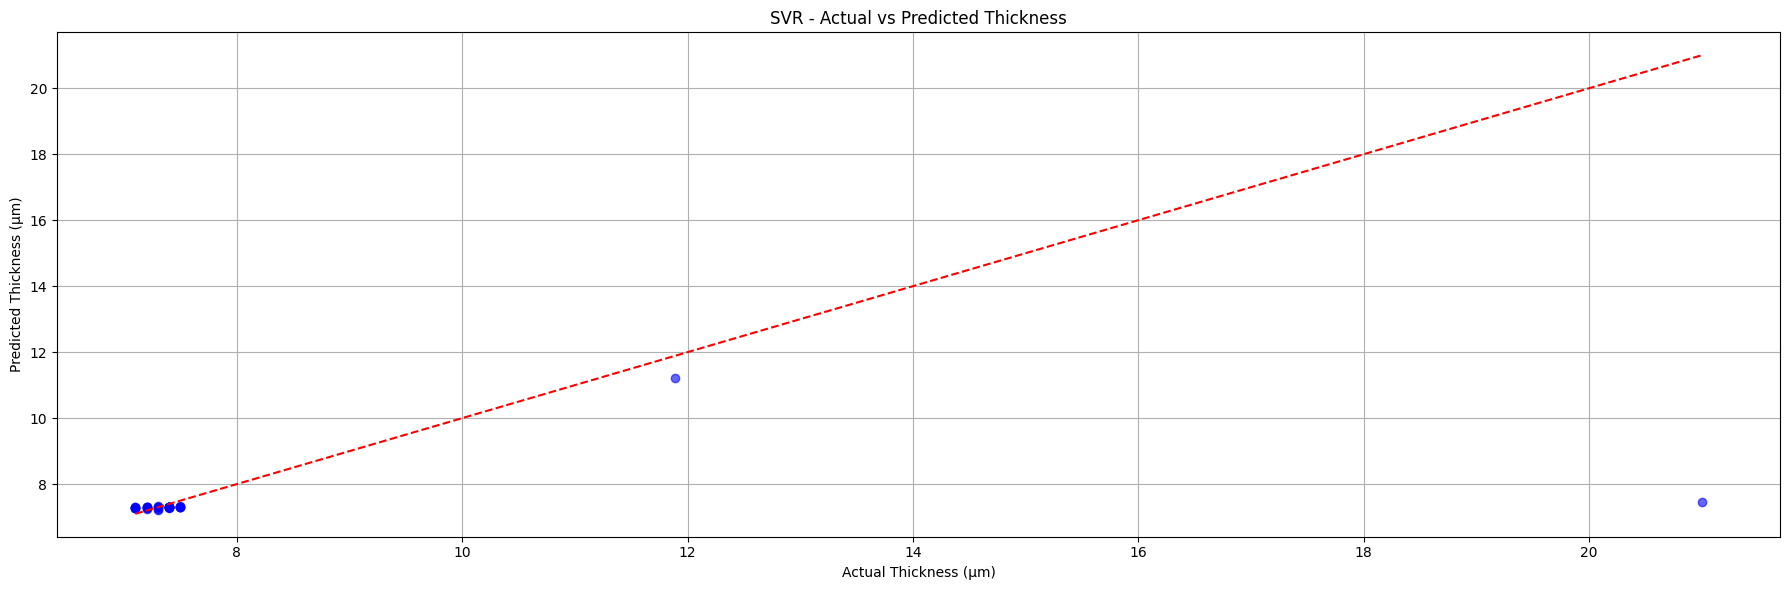

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))
plt.scatter(new_prediction_svr.y_test.values, new_prediction_svr.svr_predicted.values, color='blue', alpha=0.6)
plt.plot([new_prediction_svr.y_test.values.min(), new_prediction_svr.y_test.values.max()], [new_prediction_svr.y_test.values.min(), new_prediction_svr.y_test.values.max()], 'r--')  # 45-degree line
plt.xlabel('Actual Thickness (µm)')
plt.ylabel('Predicted Thickness (µm)')
plt.title('SVR - Actual vs Predicted Thickness')
plt.grid(True)
plt.tight_layout()
plt.show()


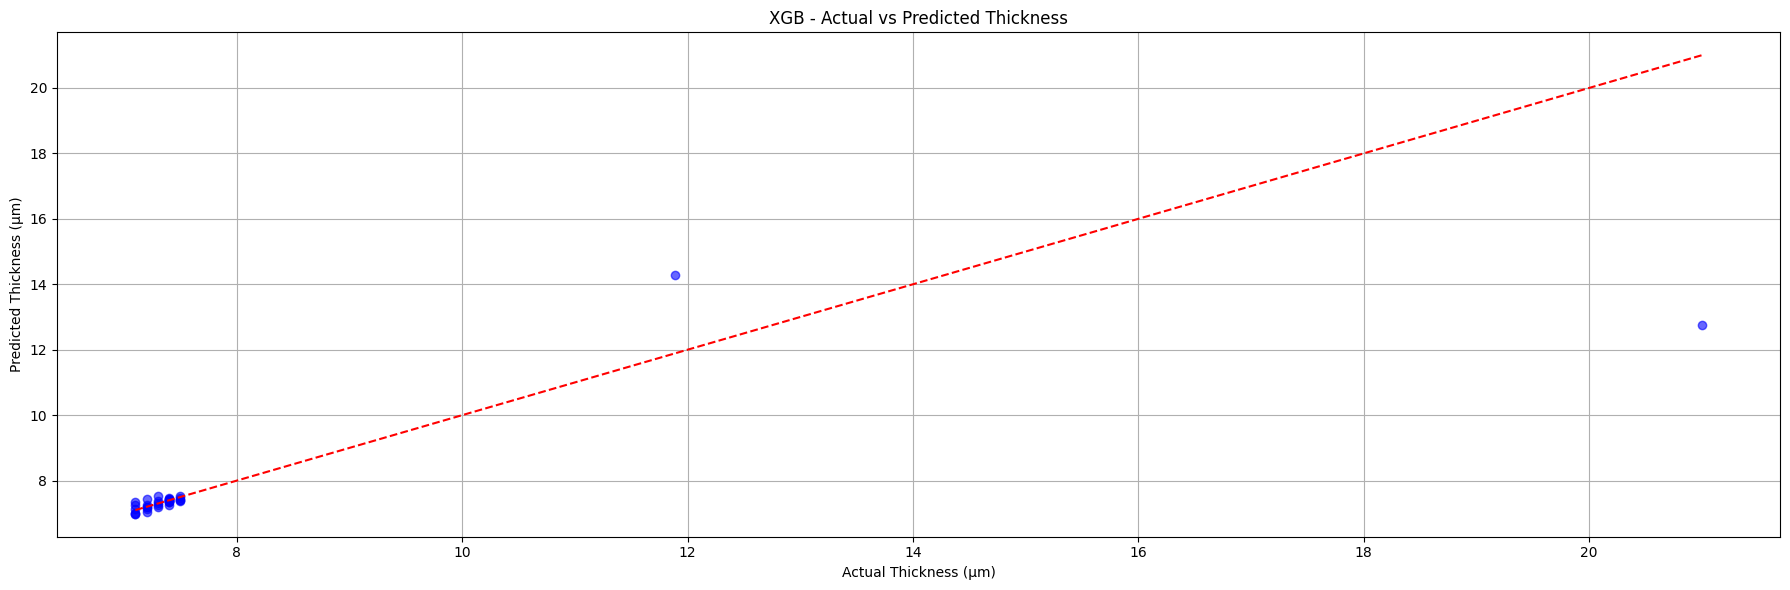

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))
plt.scatter(new_prediction_xgb.y_test.values, new_prediction_xgb.xgboost_predicted.values, color='blue', alpha=0.6)
plt.plot([new_prediction_xgb.y_test.values.min(), new_prediction_xgb.y_test.values.max()], [new_prediction_xgb.y_test.values.min(), new_prediction_xgb.y_test.values.max()], 'r--')  # 45-degree line
plt.xlabel('Actual Thickness (µm)')
plt.ylabel('Predicted Thickness (µm)')
plt.title('XGB - Actual vs Predicted Thickness')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
new_df

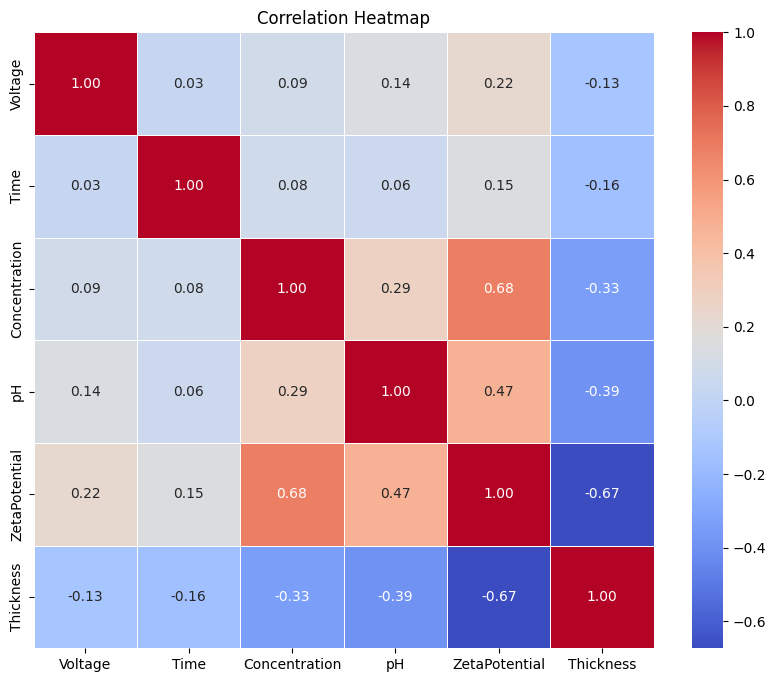

In [ ]:
# 3. Heatmap of Correlation
plt.figure(figsize=(10, 8))
correlation_matrix = new_df[['Voltage', 'Time', 'Concentration', 'pH', 'ZetaPotential', 'Thickness']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()
